# 3C - Precursores: o que antecede o pico do Nino 3.4?

**Pergunta especifica.** Quais variaveis lideram a SSTA Nino 3.4 e em que lag semanal aparece o maior acoplamento?

**Objetivo.** Produzir uma triagem ampla de hipoteses fisicas: recarga, termoclina, SSH, vento, Atlantico e DHW.

**Justificativa.** 3C nao e evidencia final; e ordenacao. Ele separa coincidencia em lag 0 de antecedencia real em lags positivos e orienta o rigor estatistico do 3D.

**Metodologia.** Calcula correlacao `preditor[t-lag]` versus `SSTA[t]` em janela comum 1993+, com lags 0-78 semanas. Tambem calcula mapa longitude x lag na banda equatorial 2S-2N.

**Saidas.** `phase3C_lag_correlacoes.csv`, `phase3C_precursor_ranking.csv`, `phase3C_mapa_lon_lag.csv`, `phase3C_heatmap_lags.png`, `phase3C_mapa_lon_lag.png`.


In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, '.')
import fase3_utils as u

weekly = pd.read_csv(u.FEAT / 'phase3_indices_semanais.csv', parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
target = weekly['nino34_ssta']
COMMON = '1993-01-01'
LAGS = range(0, 79)
predictors = [c for c in weekly.columns if c != 'nino34_ssta']

def lag_corr_frame(df, target, lags):
    out = {}
    for col in df.columns:
        x = df[col]
        out[col] = {lag: target.corr(x.shift(lag)) for lag in lags}
    return pd.DataFrame(out)

lc_common = lag_corr_frame(weekly.loc[COMMON:, predictors], target.loc[COMMON:], LAGS)
lc_full = lag_corr_frame(weekly[predictors], target, LAGS)
lc_common.rename_axis('lag_semanas').to_csv(u.STATS / 'phase3C_lag_correlacoes.csv')
print('[tabela] phase3C_lag_correlacoes.csv (janela comum 1993+)')
lc_common.round(3).head(3)

[tabela] phase3C_lag_correlacoes.csv (janela comum 1993+)


,d20_m,ohc_0_300,ohc_0_700,wwv,tilt_m,ssh_m,sss,atl3_ssta,atl4_ssta,tna_ssta,tsa_ssta,dhw_12w,dhw_26w_p90,tau_x_proxy_nino34_pa
0,0.404,0.699,0.673,0.218,0.772,0.724,-0.154,0.123,0.021,0.184,0.184,0.612,0.483,0.411
1,0.427,0.712,0.684,0.248,0.763,0.736,-0.138,0.110,0.004,0.170,0.169,0.596,0.457,0.438
2,0.446,0.722,0.692,0.275,0.751,0.745,-0.123,0.102,-0.011,0.157,0.156,0.579,0.431,0.433


In [2]:
# Ranking preliminar: |r| maximo e lag correspondente (janela comum 1993+)
rank = pd.DataFrame({
    'r_max_abs': lc_common.abs().max(),
    'lag_do_max_semanas': lc_common.abs().idxmax(),
}).sort_values('r_max_abs', ascending=False)
rank['r_no_lag_max'] = [round(lc_common.loc[l, v], 3) for v, l in zip(rank.index, rank['lag_do_max_semanas'])]
rank['r_max_1982_full'] = [round(lc_full.abs()[v].max(), 3) for v in rank.index]
rank['soh_superficie'] = rank.index.isin(['atl3_ssta','atl4_ssta','tna_ssta','tsa_ssta','dhw_12w','dhw_26w_p90','tau_x_proxy_nino34_pa'])
rank['familia_fisica'] = ['dhw' if v.startswith('dhw_') else ('atlantico' if v.endswith('_ssta') and v != 'nino34_ssta' else ('recarga' if v in ['d20_m','ohc_0_300','ohc_0_700','wwv','tilt_m','ssh_m'] else 'outro')) for v in rank.index]
u.save_table(rank.rename_axis('variavel'), 'phase3C_precursor_ranking.csv')
rank.round(3)


[tabela] data\processed\parquet\statistics\phase3C_precursor_ranking.csv


,r_max_abs,lag_do_max_semanas,r_no_lag_max,r_max_1982_full,soh_superficie,familia_fisica
tilt_m,0.772,0,0.772,0.784,False,recarga
ssh_m,0.755,6,0.755,0.759,False,recarga
ohc_0_300,0.738,6,0.738,0.748,False,recarga
ohc_0_700,0.701,6,0.701,0.702,False,recarga
dhw_12w,0.612,0,0.612,0.597,True,dhw
d20_m,0.545,15,0.545,0.552,False,recarga
wwv,0.516,20,0.516,0.423,False,recarga
dhw_26w_p90,0.483,0,0.483,0.478,True,dhw
tau_x_proxy_nino34_pa,0.438,1,0.438,0.460,True,outro
atl4_ssta,0.264,25,-0.264,0.235,True,atlantico


[figura] data\processed\figures\fase3\phase3C_heatmap_lags.png


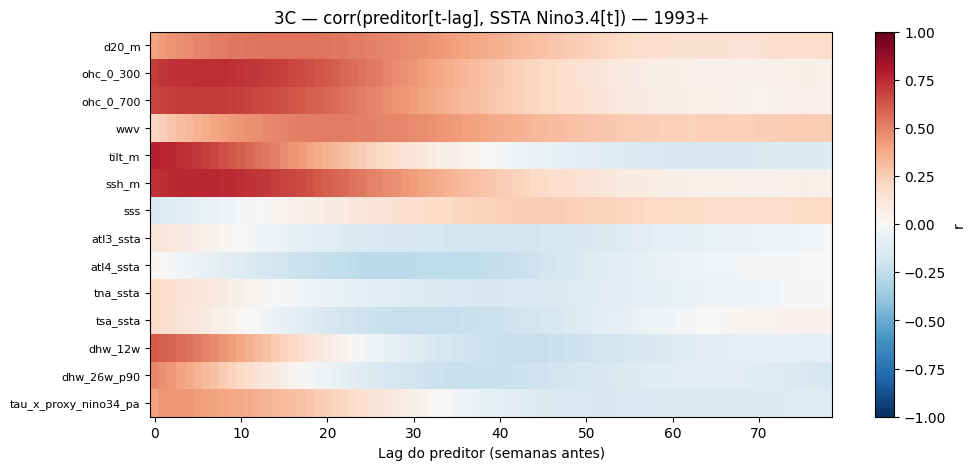

In [3]:
# Figura 3C-1: heatmap variavel x lag
fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(lc_common.T.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_yticks(range(len(lc_common.columns))); ax.set_yticklabels(lc_common.columns, fontsize=8)
ax.set_xlabel('Lag do preditor (semanas antes)'); ax.set_title('3C — corr(preditor[t-lag], SSTA Nino3.4[t]) — 1993+')
fig.colorbar(im, ax=ax, label='r')
u.save_fig(fig, 'phase3C_heatmap_lags.png')
plt.show()

[figura] data\processed\figures\fase3\phase3C_mapa_lon_lag.png
[tabela] phase3C_mapa_lon_lag.csv


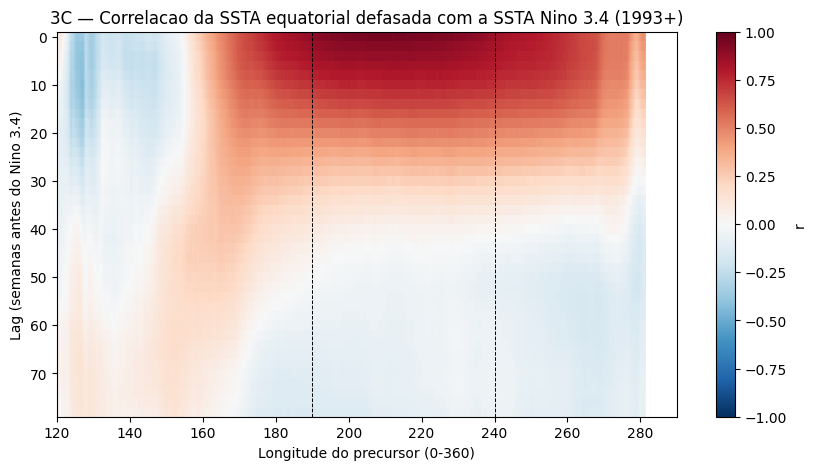

In [4]:
# Mapa 3C-1: lon x lag — de onde vem o sinal que chega ao Nino 3.4
eq = u.load_eqband_weekly().loc[COMMON:]
tgt = target.loc[COMMON:]
eq_al, tgt_al = eq.align(tgt, join='inner', axis=0)
lags_map = range(0, 79, 2)
lonlag = np.full((len(lags_map), eq_al.shape[1]), np.nan)
tv = tgt_al.values
for i, lag in enumerate(lags_map):
    shifted = eq_al.shift(lag).values
    for j in range(eq_al.shape[1]):
        x = shifted[:, j]
        m = np.isfinite(x) & np.isfinite(tv)
        if m.sum() > 100:
            lonlag[i, j] = np.corrcoef(x[m], tv[m])[0, 1]
lon = eq_al.columns.values
fig, ax = plt.subplots(figsize=(10, 5))
pc = ax.pcolormesh(lon, list(lags_map), lonlag, cmap='RdBu_r', vmin=-1, vmax=1, shading='auto')
ax.axvline(190, color='k', ls='--', lw=0.7); ax.axvline(240, color='k', ls='--', lw=0.7)
ax.invert_yaxis()
ax.set_xlabel('Longitude do precursor (0-360)'); ax.set_ylabel('Lag (semanas antes do Nino 3.4)')
ax.set_title('3C — Correlacao da SSTA equatorial defasada com a SSTA Nino 3.4 (1993+)')
fig.colorbar(pc, ax=ax, label='r')
u.save_fig(fig, 'phase3C_mapa_lon_lag.png')
pd.DataFrame(lonlag, index=list(lags_map), columns=lon).rename_axis('lag_semanas').to_csv(u.STATS / 'phase3C_mapa_lon_lag.csv')
print('[tabela] phase3C_mapa_lon_lag.csv')
plt.show()

**Leitura do 3C.** O ranking preliminar identifica quais blocos lideram o Niño 3.4 e com quanta antecedência — tipicamente o bloco de recarga (WWV/OHC/D20) mantém correlação alta em lags de 1–2 trimestres, enquanto o Atlântico e o τx aparecem mais fracos e/ou defasados. O mapa lon×lag mostra a inclinação característica oeste→leste: anomalias no Pacífico central-oeste antecedem a caixa Niño 3.4, coerente com propagação de ondas de Kelvin e advecção zonal. **Nada aqui é significância**: o corte formal (N_eff, FDR, IC95) é feito no 3D e a estabilidade no 3E — só o que sobrevive aos dois entra no parecer.